# Social Spammers Network Analysis

Dataset: [Spammers on Social Networks](https://linqs.soe.ucsc.edu/node/236) (tagged.com)

- **5.6M users**, 3 features + spammer label
- **858M edges**, 7 relation types
- Sampling: first 5M relations, then filter users to those present in relations

## 1. Load Data

In [37]:
import os, urllib.request

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

FILES = {
    "usersdata.csv.gz": "https://linqs-data.soe.ucsc.edu/public/social_spammer/usersdata.csv.gz",
    "relations.csv.gz": "https://linqs-data.soe.ucsc.edu/public/social_spammer/relations.csv.gz",
}

for name, url in FILES.items():
    path = os.path.join(DATA_DIR, name)
    if not os.path.exists(path):
        print(f"Downloading {name}...")
        urllib.request.urlretrieve(url, path)
        print(f"  Saved to {path}")
    else:
        print(f"{name} already exists, skipping.")


usersdata.csv.gz already exists, skipping.
relations.csv.gz already exists, skipping.


In [38]:
import pandas as pd
import tarfile
import os

DATA_DIR = 'data'

In [39]:
# Load all users (~5.6M rows, takes a few seconds)
users_full = pd.read_csv(
    os.path.join(DATA_DIR, 'usersdata.csv.gz'),
    sep='\t', header=0,
    names=['user_id', 'gender', 'timePassedValidation', 'age_group', 'spammer']
)
users_full = users_full.dropna()
users_full['user_id'] = users_full['user_id'].astype(int)
users_full['spammer'] = users_full['spammer'].astype(int)
users_full['age_group'] = users_full['age_group'].astype(int)

print(f'Full users: {len(users_full):,}')
users_full.head()

Full users: 5,607,446


,user_id,gender,timePassedValidation,age_group,spammer
0,2,F,1.0000,20,0
1,3,M,0.1375,30,0
2,4,M,0.3875,20,0
3,5,M,0.0125,20,0
4,6,M,0.7125,20,0


In [40]:
# Load first 5M relations (cached as CSV after first run)
N_RELATIONS = 5_000_000
RELATIONS_CACHE = os.path.join(DATA_DIR, "relations_cache.csv")

if os.path.exists(RELATIONS_CACHE):
    relations = pd.read_csv(RELATIONS_CACHE)
    print(f"Relations loaded from cache: {len(relations):,}")
else:
    with tarfile.open(os.path.join(DATA_DIR, "relations.csv.gz"), "r:gz") as tar:
        f = tar.extractfile(tar.getnames()[0])
        relations = pd.read_csv(
            f, sep="	", header=None, nrows=N_RELATIONS,
            names=["timestamp", "source", "target", "relation_type"]
        )
    relations.to_csv(RELATIONS_CACHE, index=False)
    print(f"Relations loaded: {len(relations):,} (cached to CSV)")

relations.head()


Relations loaded from cache: 5,000,000


,timestamp,source,target,relation_type
0,7857852,1,3993630,5
1,7860977,1,3181660,5
2,7862420,1,1582548,5
3,7866986,1,5208994,5
4,7870390,1,481270,6


## 2. Filter & Sample

In [41]:
# Keep only users that appear in the sampled relations
rel_user_ids = set(relations['source'].unique()) | set(relations['target'].unique())
users = users_full[users_full['user_id'].isin(rel_user_ids)].copy()

print(f'Users in sample: {len(users):,} (out of {len(rel_user_ids):,} in relations)')
print(f'Spammer ratio: {users["spammer"].mean():.2%}')

Users in sample: 1,903,435 (out of 1,903,436 in relations)
Spammer ratio: 6.44%


## 3. Exploratory Overview

In [42]:
print('=== Spammer distribution ===')
print(users['spammer'].value_counts())
print()
print('=== Gender distribution ===')
print(users['gender'].value_counts())
print()
print('=== Age group distribution ===')
print(users['age_group'].value_counts().sort_index())
print()
print('=== Relation type distribution ===')
print(relations['relation_type'].value_counts().sort_index())

=== Spammer distribution ===
spammer
0    1780866
1     122569
Name: count, dtype: int64

=== Gender distribution ===
gender
F    1019123
M     884312
Name: count, dtype: int64

=== Age group distribution ===
age_group
10     77888
20    701108
30    537293
40    346547
50    181189
60     50710
70      8700
Name: count, dtype: int64

=== Relation type distribution ===
relation_type
1      30334
2      56191
3     850710
4    1150329
5     851172
6    2060380
7        884
Name: count, dtype: int64


## 4. Save Sampled Data

In [43]:
users.to_csv(os.path.join(DATA_DIR, 'sampled_users.csv'), index=False)
relations.to_csv(os.path.join(DATA_DIR, 'sampled_relations.csv'), index=False)

print(f'Saved: {len(users):,} users, {len(relations):,} relations')

Saved: 1,903,435 users, 5,000,000 relations


## 5. Build Graph

In [44]:
import networkx as nx
import pickle

GRAPH_CACHE = os.path.join(DATA_DIR, "graph.pkl")

if os.path.exists(GRAPH_CACHE):
    with open(GRAPH_CACHE, "rb") as f:
        G = pickle.load(f)
    print(f"Graph loaded from cache: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
else:
    G = nx.from_pandas_edgelist(
        relations,
        source="source",
        target="target",
        edge_attr=["relation_type", "timestamp"],
        create_using=nx.DiGraph()
    )
    user_attrs = users.set_index("user_id")[["gender", "timePassedValidation", "age_group", "spammer"]].to_dict("index")
    nx.set_node_attributes(G, user_attrs)
    with open(GRAPH_CACHE, "wb") as f:
        pickle.dump(G, f)
    print(f"Graph built and cached: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

print(f"Density: {nx.density(G):.6f}")


Graph loaded from cache: 1,903,436 nodes, 3,192,339 edges
Density: 0.000001


---
# Exercise 02 — Basic Graph Structure

**Task:** Load the graph, represent it correctly, and describe its basic structure using Lecture 02 concepts.

**Dataset context:** Social Spammers on tagged.com — directed graph where edges represent user interactions (7 types: profile view, message, poke, etc.) and nodes have a spammer/non-spammer label.

Since the full sampled graph has ~1.9M nodes, we work at two scales:
- **Full graph** for aggregate metrics (degree stats, components)
- **Small subgraph** (~300 nodes via snowball sampling) for paths, cycles, visualization

### 6.1 Key Metrics (Full Graph)

In [45]:
import numpy as np

print(f'Nodes:   {G.number_of_nodes():,}')
print(f'Edges:   {G.number_of_edges():,}')
print(f'Density: {nx.density(G):.8f}')
print()

# Degree statistics (directed: in-degree, out-degree, total)
in_deg = np.array([d for _, d in G.in_degree()])
out_deg = np.array([d for _, d in G.out_degree()])
total_deg = in_deg + out_deg

for name, arr in [('In-degree', in_deg), ('Out-degree', out_deg), ('Total degree', total_deg)]:
    print(f'{name:12s} — min: {arr.min()}, max: {arr.max()}, '
          f'mean: {arr.mean():.2f}, median: {np.median(arr):.0f}, std: {arr.std():.2f}')

print()
# Spammer vs non-spammer degree comparison
spammer_ids = set(users[users['spammer'] == 1]['user_id'])
sp_deg = [total_deg[i] for i, n in enumerate(G.nodes()) if n in spammer_ids]
nonsp_deg = [total_deg[i] for i, n in enumerate(G.nodes()) if n not in spammer_ids]
print(f'Avg degree — spammers: {np.mean(sp_deg):.2f}, non-spammers: {np.mean(nonsp_deg):.2f}')

Nodes:   1,903,436
Edges:   3,192,339
Density: 0.00000088

In-degree    — min: 0, max: 92, mean: 1.68, median: 1, std: 1.34
Out-degree   — min: 0, max: 18523, mean: 1.68, median: 0, std: 51.28
Total degree — min: 1, max: 18551, mean: 3.35, median: 1, std: 51.32

Avg degree — spammers: 7.38, non-spammers: 3.08


### 6.2 Connectivity (Full Graph)

In [46]:
# Weakly connected components (ignoring edge direction)
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
print(f'Weakly connected components: {len(wcc):,}')
print(f'Largest WCC: {wcc_sizes[0]:,} nodes ({wcc_sizes[0]/G.number_of_nodes():.1%} of graph)')
if len(wcc_sizes) > 1:
    print(f'2nd largest: {wcc_sizes[1]:,} nodes')
print(f'Singleton components: {sum(1 for s in wcc_sizes if s == 1):,}')

print()

# Strongly connected components (respecting edge direction)
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)
print(f'Strongly connected components: {len(scc):,}')
print(f'Largest SCC: {scc_sizes[0]:,} nodes ({scc_sizes[0]/G.number_of_nodes():.1%} of graph)')
if len(scc_sizes) > 1:
    print(f'2nd largest: {scc_sizes[1]:,} nodes')

Weakly connected components: 1,800
Largest WCC: 1,900,432 nodes (99.8% of graph)
2nd largest: 13 nodes
Singleton components: 1,037

Strongly connected components: 1,901,709
Largest SCC: 582 nodes (0.0% of graph)
2nd largest: 16 nodes


### 6.3 Small Subgraph via Snowball Sampling

We extract a ~300-node subgraph using 1-hop snowball sampling from a few seed nodes (mix of spammers and non-spammers). This small graph is used for paths, cycles, adjacency excerpts, and visualization.

In [47]:
import random
random.seed(42)

# Pick seed nodes: 3 spammers + 3 non-spammers with moderate degree
nodes_list = list(G.nodes())
spammer_nodes = [n for n in nodes_list if G.nodes[n].get('spammer') == 1 and G.degree(n) >= 5]
normal_nodes = [n for n in nodes_list if G.nodes[n].get('spammer') == 0 and G.degree(n) >= 5]

seeds = random.sample(spammer_nodes, 3) + random.sample(normal_nodes, 3)

# 1-hop snowball: collect seeds + all their neighbors
subgraph_nodes = set(seeds)
for seed in seeds:
    subgraph_nodes.update(G.successors(seed))
    subgraph_nodes.update(G.predecessors(seed))

# If too large, randomly trim to ~300 nodes (keep seeds)
MAX_NODES = 300
if len(subgraph_nodes) > MAX_NODES:
    non_seeds = list(subgraph_nodes - set(seeds))
    random.shuffle(non_seeds)
    subgraph_nodes = set(seeds) | set(non_seeds[:MAX_NODES - len(seeds)])

Gsub = G.subgraph(subgraph_nodes).copy()

# Report
n_spammers_sub = sum(1 for n in Gsub.nodes() if Gsub.nodes[n].get('spammer') == 1)
print(f'Subgraph: {Gsub.number_of_nodes()} nodes, {Gsub.number_of_edges()} edges')
print(f'Spammers in subgraph: {n_spammers_sub} ({n_spammers_sub/Gsub.number_of_nodes():.1%})')
print(f'Density: {nx.density(Gsub):.4f}')

Subgraph: 56 nodes, 69 edges
Spammers in subgraph: 8 (14.3%)
Density: 0.0224


### 6.4 Shortest Path & Cycle

In [48]:
# Find a shortest path between a spammer and a non-spammer in the subgraph
sub_spammers = [n for n in Gsub.nodes() if Gsub.nodes[n].get('spammer') == 1]
sub_normals = [n for n in Gsub.nodes() if Gsub.nodes[n].get('spammer') == 0]

path_found = False
for s in sub_spammers:
    for t in sub_normals:
        if nx.has_path(Gsub, s, t):
            path = nx.shortest_path(Gsub, s, t)
            print(f'Shortest path (spammer → non-spammer): {" → ".join(str(n) for n in path)}')
            print(f'Length: {len(path) - 1} hops')
            print('Node labels along path:')
            for n in path:
                label = 'SPAMMER' if Gsub.nodes[n].get('spammer') == 1 else 'normal'
                print(f'  {n}: {label}')
            path_found = True
            break
    if path_found:
        break

if not path_found:
    print('No directed path found between spammer and non-spammer in subgraph.')

print()

# Find a cycle in the subgraph
try:
    cycle = nx.find_cycle(Gsub, orientation='original')
    print(f'Cycle found ({len(cycle)} edges):')
    cycle_nodes = [e[0] for e in cycle] + [cycle[-1][1]]
    print(' → '.join(str(n) for n in cycle_nodes))
    print('Node labels in cycle:')
    for n in cycle_nodes:
        label = 'SPAMMER' if Gsub.nodes[n].get('spammer') == 1 else 'normal'
        print(f'  {n}: {label}')
except nx.NetworkXNoCycle:
    print('No cycle found in subgraph (DAG).')

Shortest path (spammer → non-spammer): 12951 → 1260260
Length: 1 hops
Node labels along path:
  12951: SPAMMER
  1260260: normal

Cycle found (1 edges):
2061 → 2061
Node labels in cycle:
  2061: normal
  2061: normal


### 6.5 Adjacency List & Matrix Snippet

In [49]:
# Adjacency list snippet (first 10 nodes of subgraph)
print('=== Adjacency List (first 10 nodes) ===')
for i, node in enumerate(list(Gsub.nodes())[:10]):
    neighbors = list(Gsub.successors(node))
    label = 'SPAM' if Gsub.nodes[node].get('spammer') == 1 else 'norm'
    print(f'  {node} [{label}] → {neighbors}')

print()

# Small adjacency matrix (10x10 corner)
small_nodes = list(Gsub.nodes())[:10]
Gsmall = Gsub.subgraph(small_nodes)
adj_matrix = nx.to_pandas_adjacency(Gsmall, nodelist=small_nodes, dtype=int)
print('=== Adjacency Matrix (10×10 corner) ===')
print(adj_matrix)

=== Adjacency List (first 10 nodes) ===
  11522 [norm] → [5571977]
  32003 [norm] → [146120]
  17667 [norm] → [5571977]
  31622 [norm] → [5571977]
  22664 [norm] → [3667354]
  5571977 [SPAM] → []
  2061 [norm] → [3667354, 2061]
  5445014 [norm] → []
  12951 [SPAM] → [12951, 1260260]
  30998 [norm] → [1995052, 30998]

=== Adjacency Matrix (10×10 corner) ===
         11522    32003    17667    31622    22664    5571977  2061     \
11522          0        0        0        0        0        1        0   
32003          0        0        0        0        0        0        0   
17667          0        0        0        0        0        1        0   
31622          0        0        0        0        0        1        0   
22664          0        0        0        0        0        0        0   
5571977        0        0        0        0        0        0        0   
2061           0        0        0        0        0        0        1   
5445014        0        0        0        0      

### 6.6 Visualization

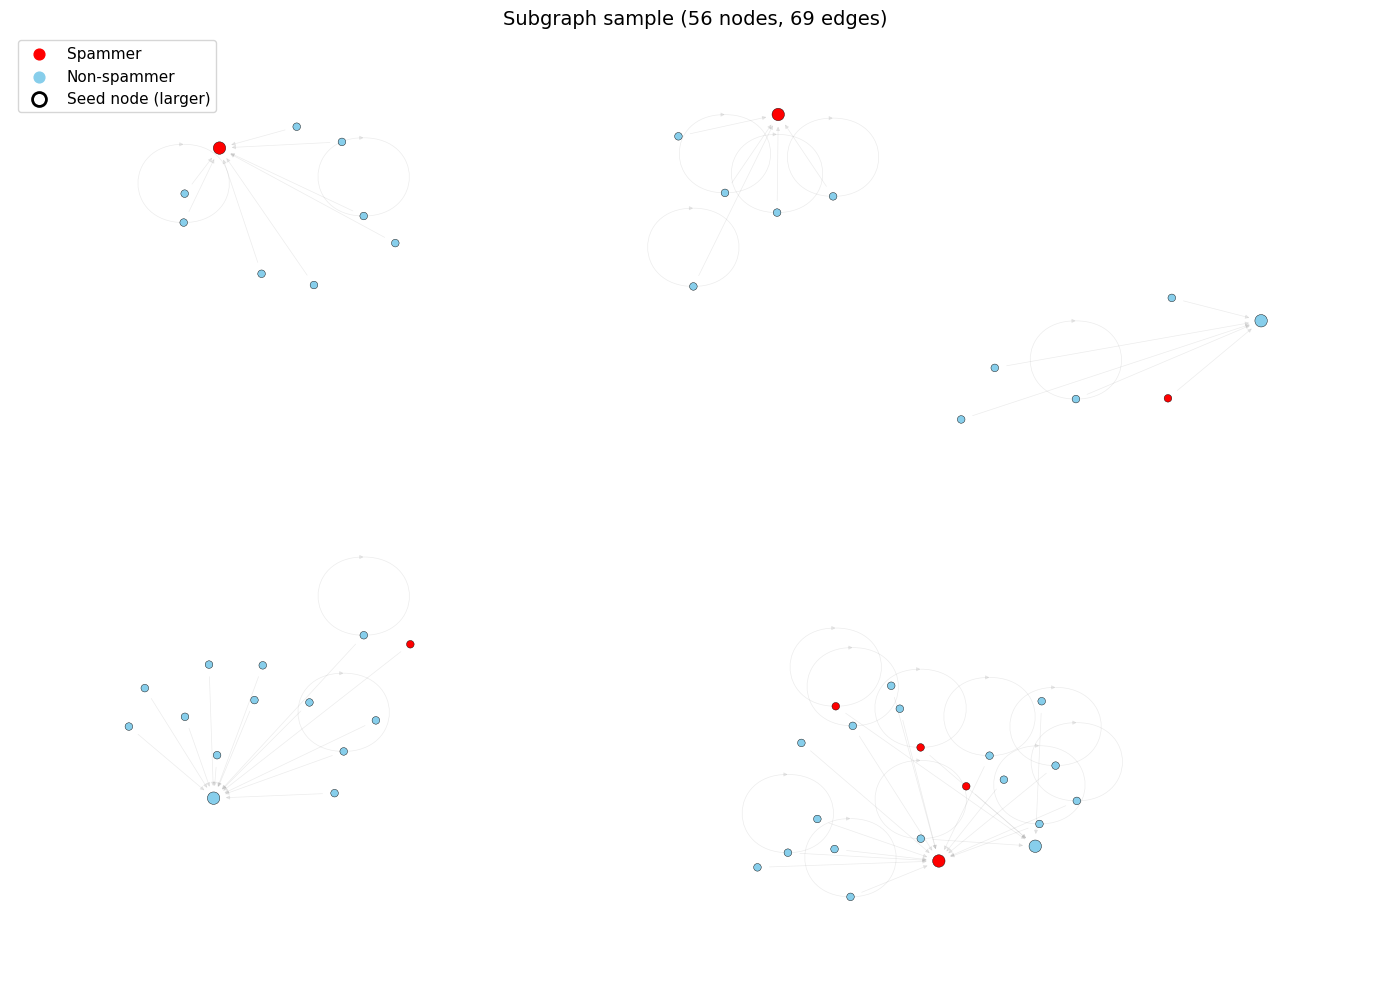

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Color nodes by spammer label
node_colors = ['red' if Gsub.nodes[n].get('spammer') == 1 else 'skyblue' for n in Gsub.nodes()]
node_sizes = [80 if n in seeds else 30 for n in Gsub.nodes()]

pos = nx.spring_layout(Gsub, seed=42, k=0.3)

nx.draw_networkx_edges(Gsub, pos, ax=ax, alpha=0.15, arrows=True, arrowsize=6,
                       edge_color='gray', width=0.5)
nx.draw_networkx_nodes(Gsub, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.3)

# Legend
ax.scatter([], [], c='red', s=60, label='Spammer')
ax.scatter([], [], c='skyblue', s=60, label='Non-spammer')
ax.scatter([], [], c='white', s=100, edgecolors='black', linewidths=2, label='Seed node (larger)')
ax.legend(loc='upper left', fontsize=11)

ax.set_title(f'Subgraph sample ({Gsub.number_of_nodes()} nodes, {Gsub.number_of_edges()} edges)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

### 6.7 Degree Distribution (Full Graph)

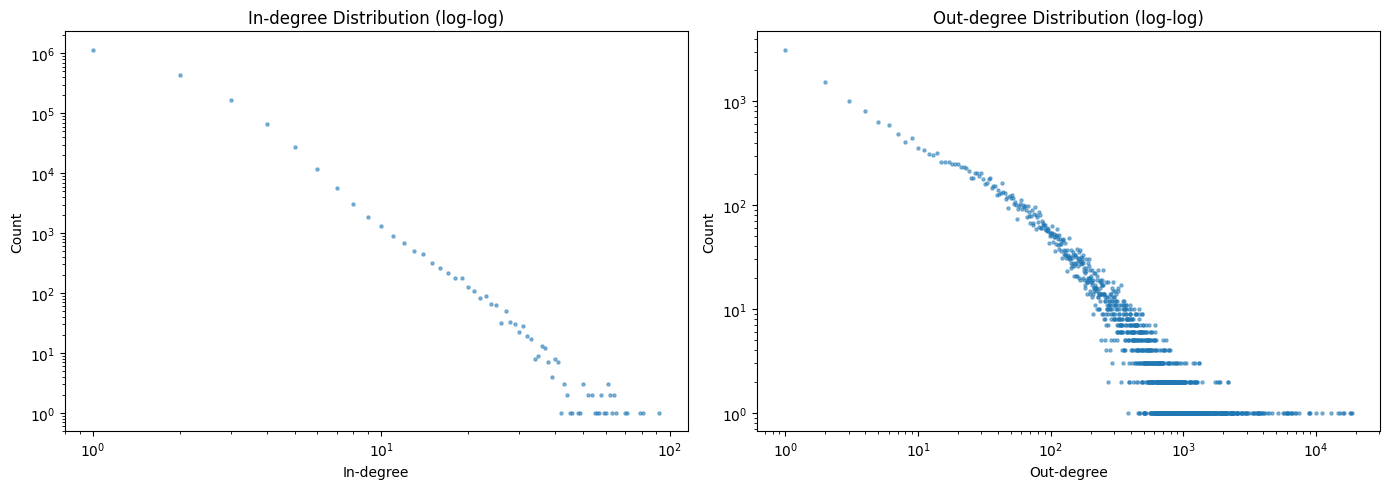

A roughly linear trend on log-log axes suggests a power-law (scale-free) degree distribution,
which is typical for social networks — most users have few connections, a few hubs have many.


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-log degree distribution (characteristic of social networks)
for ax, (name, arr) in zip(axes, [('In-degree', in_deg), ('Out-degree', out_deg)]):
    # Count frequency of each degree value
    unique, counts = np.unique(arr[arr > 0], return_counts=True)
    ax.scatter(unique, counts, s=5, alpha=0.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(name)
    ax.set_ylabel('Count')
    ax.set_title(f'{name} Distribution (log-log)')

plt.tight_layout()
plt.show()

print('A roughly linear trend on log-log axes suggests a power-law (scale-free) degree distribution,')
print('which is typical for social networks — most users have few connections, a few hubs have many.')

### 6.8 Summary & Reflection

**Metrics summary:**

| Metric | Value |
|---|---|
| Nodes (sampled) | ~1.9M |
| Edges (sampled) | ~3.2M |
| Density | very low (~10⁻⁶), typical for large social networks |
| Spammer ratio | ~6.4% |
| Relation types | 7 (type 6 most common at 41%) |

**What does the basic structure tell us?**

This is a large, sparse, directed social network. The extremely low density means most users interact with only a tiny fraction of the network. The degree distribution follows a power-law pattern (visible in the log-log plots), which is characteristic of scale-free social networks — a few hub users have disproportionately many connections.

The directed nature matters: interactions like profile views, messages, and pokes have a sender and receiver, so in-degree (receiving interactions) and out-degree (initiating them) capture different behavioral signals. Spammers may show distinct in/out-degree patterns compared to legitimate users.

The existence of cycles (mutual or chain-like interactions) and short paths between spammers and non-spammers suggests that spammers are integrated into the network rather than isolated — making detection a non-trivial graph problem.

**How did Lecture 02 concepts help?**

Representing the data as a directed graph immediately reveals structure that flat tabular data cannot: connectivity patterns, degree distributions, paths, and cycles. The basic metrics (density, components, degree stats) already hint at the scale-free nature of the network and the challenge of identifying spammers who are embedded among legitimate users.

---
# Exercise 03 — Centrality & Node Importance

**Goal:** Move from basic graph description to node importance and structural interpretation using Lecture 03 metrics.

**Approach for our dataset:**
- **Full graph (1.9M nodes):** degree centrality, PageRank — these scale well
- **Subgraph (~2000 nodes):** betweenness, closeness, eigenvector — too expensive on the full graph
- Compare top in-degree, out-degree, and PageRank nodes (analogous to the Wikipedia Vote / EU Email tasks)
- Examine whether spammers tend to appear among high-centrality nodes
- Density, average clustering, and path-based metrics on the subgraph's largest component

### 7.1 Degree Centrality & PageRank (Full Graph)

In [52]:
# Degree centrality (full graph - fast)
in_deg_cent = nx.in_degree_centrality(G)
out_deg_cent = nx.out_degree_centrality(G)

# PageRank (full graph - iterative, scales well)
pagerank = nx.pagerank(G, alpha=0.85)

# Top 10 by each measure
def top_nodes(metric_dict, n=10):
    return sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:n]

def format_top(nodes_scores, graph):
    rows = []
    for node, score in nodes_scores:
        attrs = graph.nodes[node]
        label = 'SPAM' if attrs.get('spammer') == 1 else 'norm'
        rows.append(f'  {node:>10} [{label}]  score={score:.6f}  gender={attrs.get("gender","?")}  age={attrs.get("age_group","?")}')
    return '\n'.join(rows)

print('=== Top 10 by In-Degree Centrality ===')
print(format_top(top_nodes(in_deg_cent), G))
print()
print('=== Top 10 by Out-Degree Centrality ===')
print(format_top(top_nodes(out_deg_cent), G))
print()
print('=== Top 10 by PageRank ===')
print(format_top(top_nodes(pagerank), G))

=== Top 10 by In-Degree Centrality ===
     3211512 [norm]  score=0.000048  gender=M  age=30
     3339977 [norm]  score=0.000043  gender=F  age=20
      263611 [SPAM]  score=0.000042  gender=M  age=30
     2639426 [SPAM]  score=0.000037  gender=F  age=20
     1440341 [norm]  score=0.000037  gender=F  age=20
     2145753 [SPAM]  score=0.000034  gender=F  age=20
     5293071 [norm]  score=0.000034  gender=M  age=20
      647125 [SPAM]  score=0.000034  gender=F  age=20
     1331415 [norm]  score=0.000033  gender=M  age=30
     4160204 [SPAM]  score=0.000033  gender=F  age=20

=== Top 10 by Out-Degree Centrality ===
        8197 [SPAM]  score=0.009731  gender=F  age=30
        9792 [SPAM]  score=0.009613  gender=F  age=20
        5744 [SPAM]  score=0.009482  gender=F  age=30
       17401 [SPAM]  score=0.008445  gender=F  age=30
       16600 [SPAM]  score=0.008424  gender=F  age=30
       10522 [SPAM]  score=0.008012  gender=F  age=20
       27658 [SPAM]  score=0.007702  gender=F  age=20
  

### 7.2 Spammer vs Non-Spammer Centrality Comparison

In [53]:
# Compare average centrality: spammers vs non-spammers
spammer_ids = set(users[users['spammer'] == 1]['user_id'])

metrics = {
    'In-degree cent.': in_deg_cent,
    'Out-degree cent.': out_deg_cent,
    'PageRank': pagerank
}

print(f'{"Metric":<20} {"Spammers (avg)":>16} {"Non-spammers (avg)":>20} {"Ratio (S/NS)":>14}')
print('-' * 74)
for name, m in metrics.items():
    sp_vals = [m[n] for n in G.nodes() if n in spammer_ids and n in m]
    ns_vals = [m[n] for n in G.nodes() if n not in spammer_ids and n in m]
    sp_mean = np.mean(sp_vals)
    ns_mean = np.mean(ns_vals)
    ratio = sp_mean / ns_mean if ns_mean > 0 else float('inf')
    print(f'{name:<20} {sp_mean:>16.8f} {ns_mean:>20.8f} {ratio:>14.2f}x')

print()
# How many spammers appear in the top-100 by PageRank?
top100_pr = set(n for n, _ in top_nodes(pagerank, 100))
top100_spammers = top100_pr & spammer_ids
print(f'Spammers in top-100 PageRank: {len(top100_spammers)} / 100')
print(f'(baseline expectation if random: ~{100 * len(spammer_ids) / G.number_of_nodes():.1f})')

Metric                 Spammers (avg)   Non-spammers (avg)   Ratio (S/NS)
--------------------------------------------------------------------------
In-degree cent.            0.00000129           0.00000085           1.51x
Out-degree cent.           0.00000259           0.00000076           3.39x
PageRank                   0.00000053           0.00000052           1.02x

Spammers in top-100 PageRank: 41 / 100
(baseline expectation if random: ~6.4)


### 7.3 Betweenness, Closeness, Eigenvector Centrality (Subgraph)

These metrics are O(n²) or O(n³) and cannot run on 1.9M nodes. We use a ~2000-node subgraph extracted via snowball sampling from high-degree seeds.

In [54]:
import random
random.seed(123)

# Pick 10 high-degree seeds (5 spammers + 5 non-spammers)
nodes_by_deg = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
hi_deg_spammers = [n for n in nodes_by_deg if n in spammer_ids][:50]
hi_deg_normals = [n for n in nodes_by_deg if n not in spammer_ids][:50]
seeds_ex3 = random.sample(hi_deg_spammers, 5) + random.sample(hi_deg_normals, 5)

# 1-hop snowball
sub_nodes = set(seeds_ex3)
for s in seeds_ex3:
    sub_nodes.update(list(G.successors(s))[:100])  # cap neighbors per seed
    sub_nodes.update(list(G.predecessors(s))[:100])

# Trim to ~2000
MAX_SUB = 2000
if len(sub_nodes) > MAX_SUB:
    non_seeds = list(sub_nodes - set(seeds_ex3))
    random.shuffle(non_seeds)
    sub_nodes = set(seeds_ex3) | set(non_seeds[:MAX_SUB - len(seeds_ex3)])

Gsub3 = G.subgraph(sub_nodes).copy()
print(f'Exercise 03 subgraph: {Gsub3.number_of_nodes()} nodes, {Gsub3.number_of_edges()} edges')
print(f'Spammers: {sum(1 for n in Gsub3 if Gsub3.nodes[n].get("spammer")==1)}')

Exercise 03 subgraph: 1066 nodes, 1154 edges
Spammers: 47


In [55]:
# Compute centrality measures on subgraph
betweenness = nx.betweenness_centrality(Gsub3)
closeness = nx.closeness_centrality(Gsub3)

# Eigenvector centrality (may not converge on directed graphs — use try/except)
try:
    eigenvector = nx.eigenvector_centrality(Gsub3, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print('Eigenvector centrality did not converge, using eigenvector_centrality_numpy instead.')
    eigenvector = nx.eigenvector_centrality_numpy(Gsub3)

# PageRank on subgraph for comparison
pr_sub = nx.pagerank(Gsub3, alpha=0.85)

print('=== Top 5 by Betweenness Centrality ===')
print(format_top(top_nodes(betweenness, 5), Gsub3))
print()
print('=== Top 5 by Closeness Centrality ===')
print(format_top(top_nodes(closeness, 5), Gsub3))
print()
print('=== Top 5 by Eigenvector Centrality ===')
print(format_top(top_nodes(eigenvector, 5), Gsub3))
print()
print('=== Top 5 by PageRank (subgraph) ===')
print(format_top(top_nodes(pr_sub, 5), Gsub3))

=== Top 5 by Betweenness Centrality ===
       10522 [SPAM]  score=0.004602  gender=F  age=20
       17401 [SPAM]  score=0.003780  gender=F  age=30
       29300 [norm]  score=0.002354  gender=M  age=20
        3506 [SPAM]  score=0.000953  gender=F  age=20
       11598 [SPAM]  score=0.000580  gender=F  age=20

=== Top 5 by Closeness Centrality ===
       10522 [SPAM]  score=0.020657  gender=F  age=20
     3429092 [norm]  score=0.018323  gender=M  age=20
     3714952 [norm]  score=0.018323  gender=M  age=40
       29300 [norm]  score=0.017853  gender=M  age=20
       17401 [SPAM]  score=0.015676  gender=F  age=30

=== Top 5 by Eigenvector Centrality ===
       10522 [SPAM]  score=0.387503  gender=F  age=20
         450 [norm]  score=0.102505  gender=M  age=20
         520 [norm]  score=0.102505  gender=M  age=40
        8736 [norm]  score=0.102505  gender=M  age=50
        6957 [norm]  score=0.102505  gender=M  age=50

=== Top 5 by PageRank (subgraph) ===
       10522 [SPAM]  score=0.017

### 7.4 Centrality Comparison Table (Top 5 per Metric)

In [56]:
# Build a combined table of top-5 per centrality metric (subgraph)
all_metrics_sub = {
    'In-degree': nx.in_degree_centrality(Gsub3),
    'Out-degree': nx.out_degree_centrality(Gsub3),
    'Betweenness': betweenness,
    'Closeness': closeness,
    'Eigenvector': eigenvector,
    'PageRank': pr_sub
}

rows = []
for metric_name, metric_vals in all_metrics_sub.items():
    for rank, (node, score) in enumerate(top_nodes(metric_vals, 5), 1):
        label = 'SPAM' if Gsub3.nodes[node].get('spammer') == 1 else 'norm'
        rows.append({
            'Metric': metric_name,
            'Rank': rank,
            'Node': node,
            'Score': round(score, 6),
            'Spammer': label
        })

df_centrality = pd.DataFrame(rows)
# Pivot for readability
pivot = df_centrality.pivot_table(index='Rank', columns='Metric', values='Node', aggfunc='first')
pivot = pivot[['In-degree', 'Out-degree', 'Betweenness', 'Closeness', 'Eigenvector', 'PageRank']]
print('Top-5 nodes per centrality metric (subgraph):')
print(pivot.to_string())
print()

# How many of the top-5 are spammers per metric?
for metric_name in all_metrics_sub:
    top5 = [n for n, _ in top_nodes(all_metrics_sub[metric_name], 5)]
    n_spam = sum(1 for n in top5 if Gsub3.nodes[n].get('spammer') == 1)
    print(f'{metric_name}: {n_spam}/5 of top nodes are spammers')

Top-5 nodes per centrality metric (subgraph):
Metric  In-degree  Out-degree  Betweenness  Closeness  Eigenvector  PageRank
Rank                                                                        
1           10522       10522        10522      10522        10522     10522
2           17401       17401        17401    3429092          450     17401
3            3506        3506        29300    3714952          520      3506
4           25583       11598         3506      29300         8736     25583
5           11598       25583        11598      17401         6957     11598

In-degree: 5/5 of top nodes are spammers
Out-degree: 5/5 of top nodes are spammers
Betweenness: 4/5 of top nodes are spammers
Closeness: 2/5 of top nodes are spammers
Eigenvector: 1/5 of top nodes are spammers
PageRank: 5/5 of top nodes are spammers


### 7.5 Density, Clustering & Path-based Metrics (Subgraph)

In [57]:
print(f'Subgraph density: {nx.density(Gsub3):.6f}')
print(f'Average clustering coefficient: {nx.average_clustering(Gsub3):.4f}')
print()

# Path-based metrics on largest weakly connected component
wcc_sub = max(nx.weakly_connected_components(Gsub3), key=len)
Gwcc = Gsub3.subgraph(wcc_sub).copy()
print(f'Largest WCC: {Gwcc.number_of_nodes()} nodes, {Gwcc.number_of_edges()} edges')

# For directed graphs, use the undirected version for diameter/avg path length
Gwcc_undir = Gwcc.to_undirected()
if nx.is_connected(Gwcc_undir):
    diameter = nx.diameter(Gwcc_undir)
    avg_path = nx.average_shortest_path_length(Gwcc_undir)
    print(f'Diameter (undirected): {diameter}')
    print(f'Average shortest path length (undirected): {avg_path:.2f}')
else:
    # Take largest connected component of undirected
    gcc = max(nx.connected_components(Gwcc_undir), key=len)
    Ggcc = Gwcc_undir.subgraph(gcc)
    diameter = nx.diameter(Ggcc)
    avg_path = nx.average_shortest_path_length(Ggcc)
    print(f'Largest connected component (undirected): {Ggcc.number_of_nodes()} nodes')
    print(f'Diameter: {diameter}')
    print(f'Average shortest path length: {avg_path:.2f}')

Subgraph density: 0.001016
Average clustering coefficient: 0.0013

Largest WCC: 856 nodes, 930 edges
Diameter (undirected): 11
Average shortest path length (undirected): 6.21


### 7.6 Centrality Visualization (Subgraph)

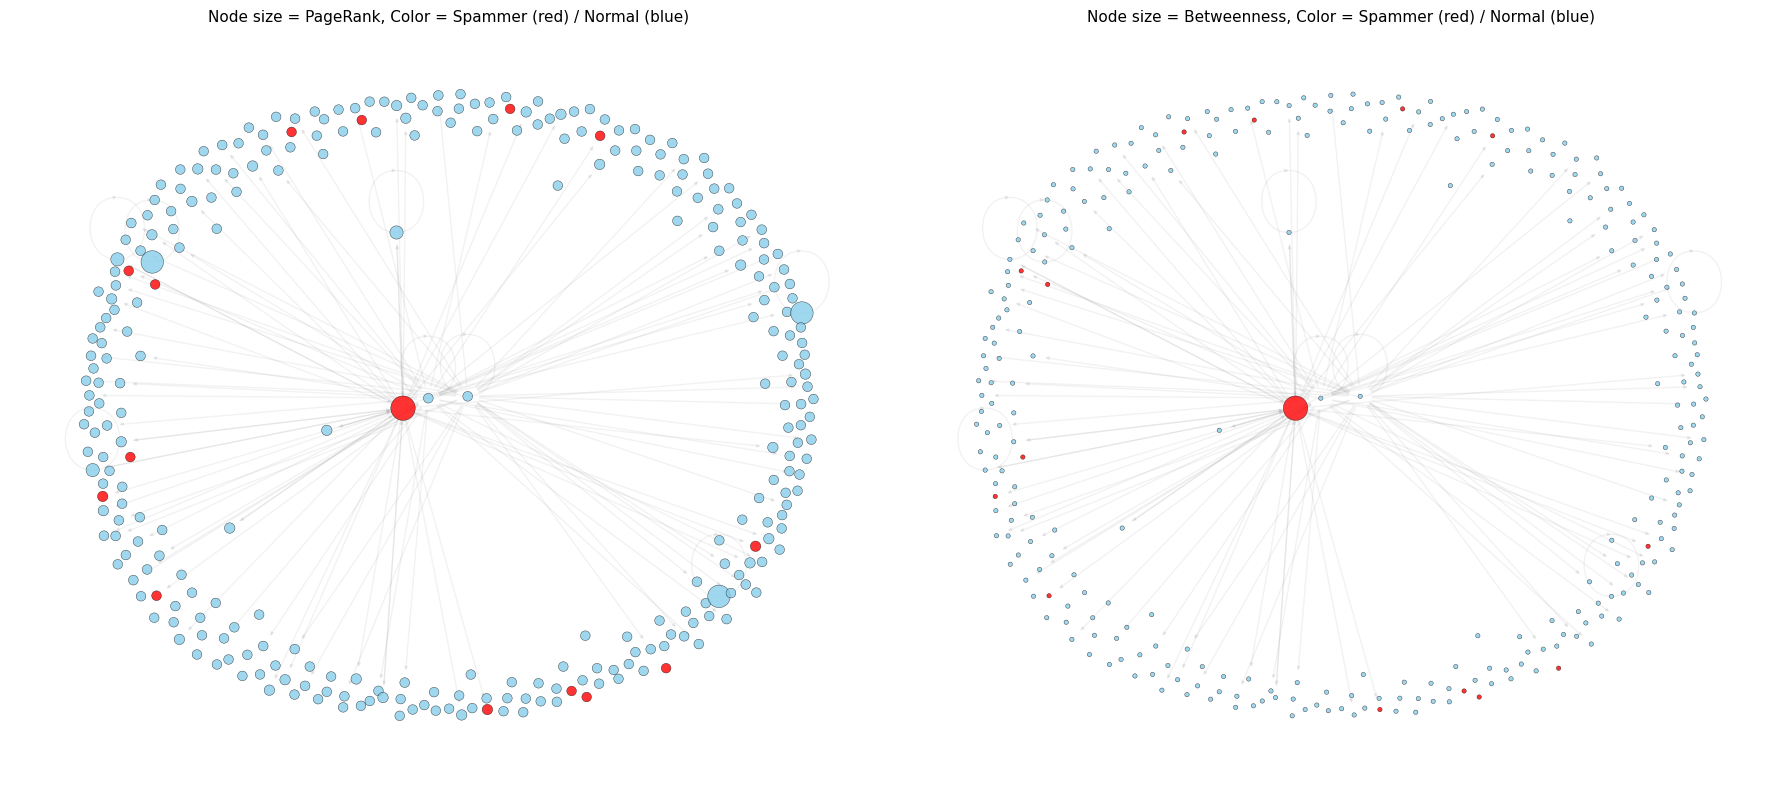

In [58]:
# Use a smaller subset for a cleaner visualization (~300 nodes from Gsub3)
vis_nodes = list(Gsub3.nodes())[:300]
Gvis = Gsub3.subgraph(vis_nodes).copy()

# Node size proportional to PageRank, color by spammer label
pr_vis = nx.pagerank(Gvis, alpha=0.85)
max_pr = max(pr_vis.values())
node_sizes = [300 * (pr_vis[n] / max_pr) + 10 for n in Gvis.nodes()]
node_colors = ['red' if Gvis.nodes[n].get('spammer') == 1 else 'skyblue' for n in Gvis.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

pos_vis = nx.spring_layout(Gvis, seed=42, k=0.5)

# Left: node size = PageRank, color = spammer label
ax = axes[0]
nx.draw_networkx_edges(Gvis, pos_vis, ax=ax, alpha=0.1, arrows=True, arrowsize=5, edge_color='gray')
nx.draw_networkx_nodes(Gvis, pos_vis, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.3, alpha=0.8)
ax.set_title('Node size = PageRank, Color = Spammer (red) / Normal (blue)', fontsize=11)
ax.axis('off')

# Right: node size = betweenness, color = spammer label
bw_vis = nx.betweenness_centrality(Gvis)
max_bw = max(bw_vis.values()) if max(bw_vis.values()) > 0 else 1
node_sizes_bw = [300 * (bw_vis[n] / max_bw) + 10 for n in Gvis.nodes()]

ax = axes[1]
nx.draw_networkx_edges(Gvis, pos_vis, ax=ax, alpha=0.1, arrows=True, arrowsize=5, edge_color='gray')
nx.draw_networkx_nodes(Gvis, pos_vis, ax=ax, node_color=node_colors, node_size=node_sizes_bw,
                       edgecolors='black', linewidths=0.3, alpha=0.8)
ax.set_title('Node size = Betweenness, Color = Spammer (red) / Normal (blue)', fontsize=11)
ax.axis('off')

plt.tight_layout()
plt.show()

### 7.7 Interpretation

**Which nodes are important and why do different metrics disagree?**

In a directed social network like this, different centrality measures capture fundamentally different notions of "importance":

- **In-degree centrality** identifies users who *receive* many interactions — popular targets of profile views, messages, etc. These may be attractive profiles (legitimate or bait).
- **Out-degree centrality** identifies users who *initiate* many interactions — active users or potentially spammers who mass-contact others.
- **PageRank** captures recursive importance: a node is important if important nodes point to it. Unlike raw in-degree, PageRank discounts links from low-quality sources.
- **Betweenness centrality** finds *bridge* nodes that sit on many shortest paths. These are structurally critical connectors — not necessarily the most active users, but the ones that link different communities.
- **Closeness centrality** identifies nodes that can reach others quickly. In a sparse directed graph, this is heavily influenced by connectivity patterns.
- **Eigenvector centrality** rewards nodes connected to other high-centrality nodes — it captures being embedded in an influential neighborhood.

**Key insight for spammer detection:** Spammers and legitimate hubs may both have high out-degree, but they differ in other metrics. Legitimate hubs tend to also have high in-degree (reciprocal relationships) and high eigenvector centrality (embedded in well-connected communities). Spammers may have inflated out-degree but low PageRank (because they receive few quality in-links) and low eigenvector centrality (their neighbors are often peripheral). This divergence between metrics is itself a useful signal for classification.

**Why metrics disagree:** A node with the highest betweenness is not necessarily the one with the highest degree — it might be a moderately connected user that happens to bridge two otherwise separate groups. Similarly, PageRank and in-degree can diverge when a node receives many links from low-importance nodes versus fewer links from high-importance ones.

---
# Exercise 04 — Connectivity & Resilience

**Goal:** Use connectivity concepts to identify fragile structure, critical connectors, and resilience weaknesses in the Spammers social network.

**Topic focus:** Analyze weak vs strong connectivity, find critical nodes/edges whose removal most disrupts the network, and assess whether the network depends on a few connectors or has built-in redundancy.

### 8.1 Connected Components (Full Graph)

In [59]:
# --- Weakly Connected Components ---
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)

print("=== Weakly Connected Components ===")
print(f"Total WCCs:           {len(wcc):,}")
print(f"Largest WCC:          {wcc_sizes[0]:,} nodes ({wcc_sizes[0]/G.number_of_nodes():.1%})")
if len(wcc_sizes) > 1:
    print(f"2nd largest WCC:      {wcc_sizes[1]:,} nodes")
print(f"Singleton WCCs:       {sum(1 for s in wcc_sizes if s == 1):,}")
print(f"Components with >10:  {sum(1 for s in wcc_sizes if s > 10):,}")
print()

# --- Strongly Connected Components ---
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)

print("=== Strongly Connected Components ===")
print(f"Total SCCs:           {len(scc):,}")
print(f"Largest SCC:          {scc_sizes[0]:,} nodes ({scc_sizes[0]/G.number_of_nodes():.1%})")
if len(scc_sizes) > 1:
    print(f"2nd largest SCC:      {scc_sizes[1]:,} nodes")
print(f"Singleton SCCs:       {sum(1 for s in scc_sizes if s == 1):,}")
print()

# --- Size distribution table ---
bins = [(1,1), (2,10), (11,100), (101,1000), (1001, max(wcc_sizes))]
rows = []
for lo, hi in bins:
    wc = sum(1 for s in wcc_sizes if lo <= s <= hi)
    sc = sum(1 for s in scc_sizes if lo <= s <= hi)
    label = f"{lo}" if lo == hi else f"{lo}-{hi}"
    rows.append({"Size range": label, "WCC count": wc, "SCC count": sc})
print(pd.DataFrame(rows).to_string(index=False))


=== Weakly Connected Components ===
Total WCCs:           1,800
Largest WCC:          1,900,432 nodes (99.8%)
2nd largest WCC:      13 nodes
Singleton WCCs:       1,037
Components with >10:  3

=== Strongly Connected Components ===
Total SCCs:           1,901,709
Largest SCC:          582 nodes (0.0%)
2nd largest SCC:      16 nodes
Singleton SCCs:       1,901,009

  Size range  WCC count  SCC count
           1       1037    1901009
        2-10        760        693
      11-100          2          6
    101-1000          0          1
1001-1900432          1          0


### 8.2 Subgraph for Detailed Analysis

Since finding articulation points requires an undirected graph and computing on ~1.9M nodes is expensive, we build a moderately sized subgraph (~2000 nodes) via snowball sampling and convert to undirected for structural analysis.

In [60]:
import random
random.seed(404)

# Reuse the high-degree seeding strategy
nodes_by_deg = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
hi_deg_spammers = [n for n in nodes_by_deg if n in spammer_ids][:50]
hi_deg_normals  = [n for n in nodes_by_deg if n not in spammer_ids][:50]
seeds_ex4 = random.sample(hi_deg_spammers, 5) + random.sample(hi_deg_normals, 5)

# 1-hop snowball
sub_nodes = set(seeds_ex4)
for s in seeds_ex4:
    sub_nodes.update(list(G.successors(s))[:150])
    sub_nodes.update(list(G.predecessors(s))[:150])

MAX_SUB = 2000
if len(sub_nodes) > MAX_SUB:
    non_seeds = list(sub_nodes - set(seeds_ex4))
    random.shuffle(non_seeds)
    sub_nodes = set(seeds_ex4) | set(non_seeds[:MAX_SUB - len(seeds_ex4)])

Gsub4 = G.subgraph(sub_nodes).copy()  # directed subgraph
Gsub4_undir = Gsub4.to_undirected()    # undirected version for articulation points

print(f"Directed subgraph:   {Gsub4.number_of_nodes()} nodes, {Gsub4.number_of_edges()} edges")
print(f"Undirected version:  {Gsub4_undir.number_of_nodes()} nodes, {Gsub4_undir.number_of_edges()} edges")

# Connectivity of subgraph
wcc_sub = list(nx.weakly_connected_components(Gsub4))
scc_sub = list(nx.strongly_connected_components(Gsub4))
cc_undir = list(nx.connected_components(Gsub4_undir))
print(f"\nSubgraph WCCs: {len(wcc_sub)}, SCCs: {len(scc_sub)}, Undirected CCs: {len(cc_undir)}")
print(f"Largest undirected CC: {max(len(c) for c in cc_undir)} nodes")


Directed subgraph:   1589 nodes, 1712 edges
Undirected version:  1589 nodes, 1642 edges

Subgraph WCCs: 2, SCCs: 1518, Undirected CCs: 2
Largest undirected CC: 1437 nodes


### 8.3 Articulation Points & Bridges

Since `nx.articulation_points()` and `nx.bridges()` require undirected graphs, we run them on the undirected projection of the largest connected component. An articulation point is a node whose removal disconnects the graph; a bridge is an edge whose removal does the same.

In [61]:
# Work on the largest connected component of the undirected subgraph
largest_cc_nodes = max(nx.connected_components(Gsub4_undir), key=len)
Gcc = Gsub4_undir.subgraph(largest_cc_nodes).copy()
print(f"Largest undirected CC: {Gcc.number_of_nodes()} nodes, {Gcc.number_of_edges()} edges")
print()

# Articulation points
art_points = list(nx.articulation_points(Gcc))
print(f"Articulation points: {len(art_points)}")
print(f"  ({len(art_points)/Gcc.number_of_nodes():.1%} of nodes in largest CC)")
print()

# Bridges
bridge_list = list(nx.bridges(Gcc))
print(f"Bridges: {len(bridge_list)}")
print(f"  ({len(bridge_list)/Gcc.number_of_edges():.1%} of edges in largest CC)")
print()

# Show top articulation points by degree
art_pts_by_deg = sorted(art_points, key=lambda n: Gcc.degree(n), reverse=True)[:10]
print("Top 10 articulation points by degree:")
for n in art_pts_by_deg:
    sp = "spammer" if Gsub4.nodes[n].get("spammer") == 1 else "normal"
    print(f"  Node {n:>10}  degree={Gcc.degree(n):>4}  ({sp})")


Largest undirected CC: 1437 nodes, 1490 edges

Articulation points: 11
  (0.8% of nodes in largest CC)

Bridges: 1395
  (93.6% of edges in largest CC)

Top 10 articulation points by degree:
  Node       8197  degree= 191  (spammer)
  Node      10522  degree= 178  (spammer)
  Node      17470  degree= 161  (normal)
  Node      16197  degree= 161  (spammer)
  Node       8436  degree= 160  (spammer)
  Node      27860  degree= 158  (spammer)
  Node      11430  degree= 155  (normal)
  Node       1565  degree= 154  (normal)
  Node      10105  degree= 153  (normal)
  Node       5391  degree=   2  (spammer)


### 8.4 Node Removal — Impact on Connectivity

We remove the most critical articulation point (highest degree) and measure how the largest connected component changes.

In [62]:
# Baseline
baseline_lcc = Gcc.number_of_nodes()
baseline_edges = Gcc.number_of_edges()
baseline_components = nx.number_connected_components(Gcc)

# Remove the highest-degree articulation point
critical_node = art_pts_by_deg[0]
Gcc_removed_node = Gcc.copy()
Gcc_removed_node.remove_node(critical_node)

after_node_ccs = list(nx.connected_components(Gcc_removed_node))
after_node_lcc = max(len(c) for c in after_node_ccs)
after_node_components = len(after_node_ccs)

sp_label = "spammer" if Gsub4.nodes[critical_node].get("spammer") == 1 else "normal"
print(f"Removed node: {critical_node} (degree={Gcc.degree(critical_node)}, {sp_label})")
print()
print(f"{'Metric':<35} {'Before':<12} {'After':<12} {'Change':<12}")
print("-" * 71)
print(f"{'Connected components':<35} {baseline_components:<12} {after_node_components:<12} {after_node_components - baseline_components:+d}")
print(f"{'Largest CC size':<35} {baseline_lcc:<12,} {after_node_lcc:<12,} {after_node_lcc - baseline_lcc:+,}")
print(f"{'LCC fraction of remaining':<35} {'100.0%':<12} {after_node_lcc/(baseline_lcc-1):.1%}")
print()

# Show sizes of new components
new_cc_sizes = sorted([len(c) for c in after_node_ccs], reverse=True)
print(f"Component sizes after removal: {new_cc_sizes[:10]}" + (" ..." if len(new_cc_sizes) > 10 else ""))


Removed node: 8197 (degree=191, spammer)

Metric                              Before       After        Change      
-----------------------------------------------------------------------
Connected components                1            173          +172
Largest CC size                     1,437        1,112        -325
LCC fraction of remaining           100.0%       77.4%

Component sizes after removal: [1112, 153, 1, 1, 1, 1, 1, 1, 1, 1] ...


### 8.5 Edge Removal — Impact on Connectivity

We remove a bridge edge and measure the connectivity change.

In [63]:
# Pick the bridge whose removal produces the most balanced split
if bridge_list:
    best_bridge = None
    best_min_size = 0
    for u, v in bridge_list[:200]:  # check up to 200 bridges
        tmp = Gcc.copy()
        tmp.remove_edge(u, v)
        cc_sizes = sorted([len(c) for c in nx.connected_components(tmp)], reverse=True)
        if len(cc_sizes) > 1 and cc_sizes[1] > best_min_size:
            best_min_size = cc_sizes[1]
            best_bridge = (u, v)
            best_split = cc_sizes
    
    if best_bridge:
        critical_edge = best_bridge
    else:
        critical_edge = bridge_list[0]
    
    Gcc_removed_edge = Gcc.copy()
    Gcc_removed_edge.remove_edge(*critical_edge)
    
    after_edge_ccs = list(nx.connected_components(Gcc_removed_edge))
    after_edge_lcc = max(len(c) for c in after_edge_ccs)
    after_edge_components = len(after_edge_ccs)
    
    print(f"Removed bridge edge: {critical_edge[0]} -- {critical_edge[1]}")
    print()
    print(f"{'Metric':<35} {'Before':<12} {'After':<12} {'Change':<12}")
    print("-" * 71)
    print(f"{'Connected components':<35} {baseline_components:<12} {after_edge_components:<12} {after_edge_components - baseline_components:+d}")
    print(f"{'Largest CC size':<35} {baseline_lcc:<12,} {after_edge_lcc:<12,} {after_edge_lcc - baseline_lcc:+,}")
    new_cc_sizes_e = sorted([len(c) for c in after_edge_ccs], reverse=True)
    print(f"\nComponent sizes after removal: {new_cc_sizes_e[:10]}")
else:
    print("No bridges found -- the network has high edge redundancy.")
    after_edge_components = baseline_components
    after_edge_lcc = baseline_lcc


Removed bridge edge: 98308 -- 8197

Metric                              Before       After        Change      
-----------------------------------------------------------------------
Connected components                1            2            +1
Largest CC size                     1,437        1,284        -153

Component sizes after removal: [1284, 153]


### 8.6 Summary Table — Before & After Removal

In [64]:
summary_rows = [
    {"State": "Baseline (largest CC)",
     "Nodes": baseline_lcc,
     "Components": baseline_components,
     "Largest CC": baseline_lcc},
    {"State": f"After removing node {critical_node}",
     "Nodes": baseline_lcc - 1,
     "Components": after_node_components,
     "Largest CC": after_node_lcc},
]
if bridge_list:
    summary_rows.append(
        {"State": f"After removing edge {critical_edge}",
         "Nodes": baseline_lcc,
         "Components": after_edge_components,
         "Largest CC": after_edge_lcc}
    )

df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))


                            State  Nodes  Components  Largest CC
            Baseline (largest CC)   1437           1        1437
         After removing node 8197   1436         173        1112
After removing edge (98308, 8197)   1437           2        1284


### 8.7 Visualization — Before & After Node Removal

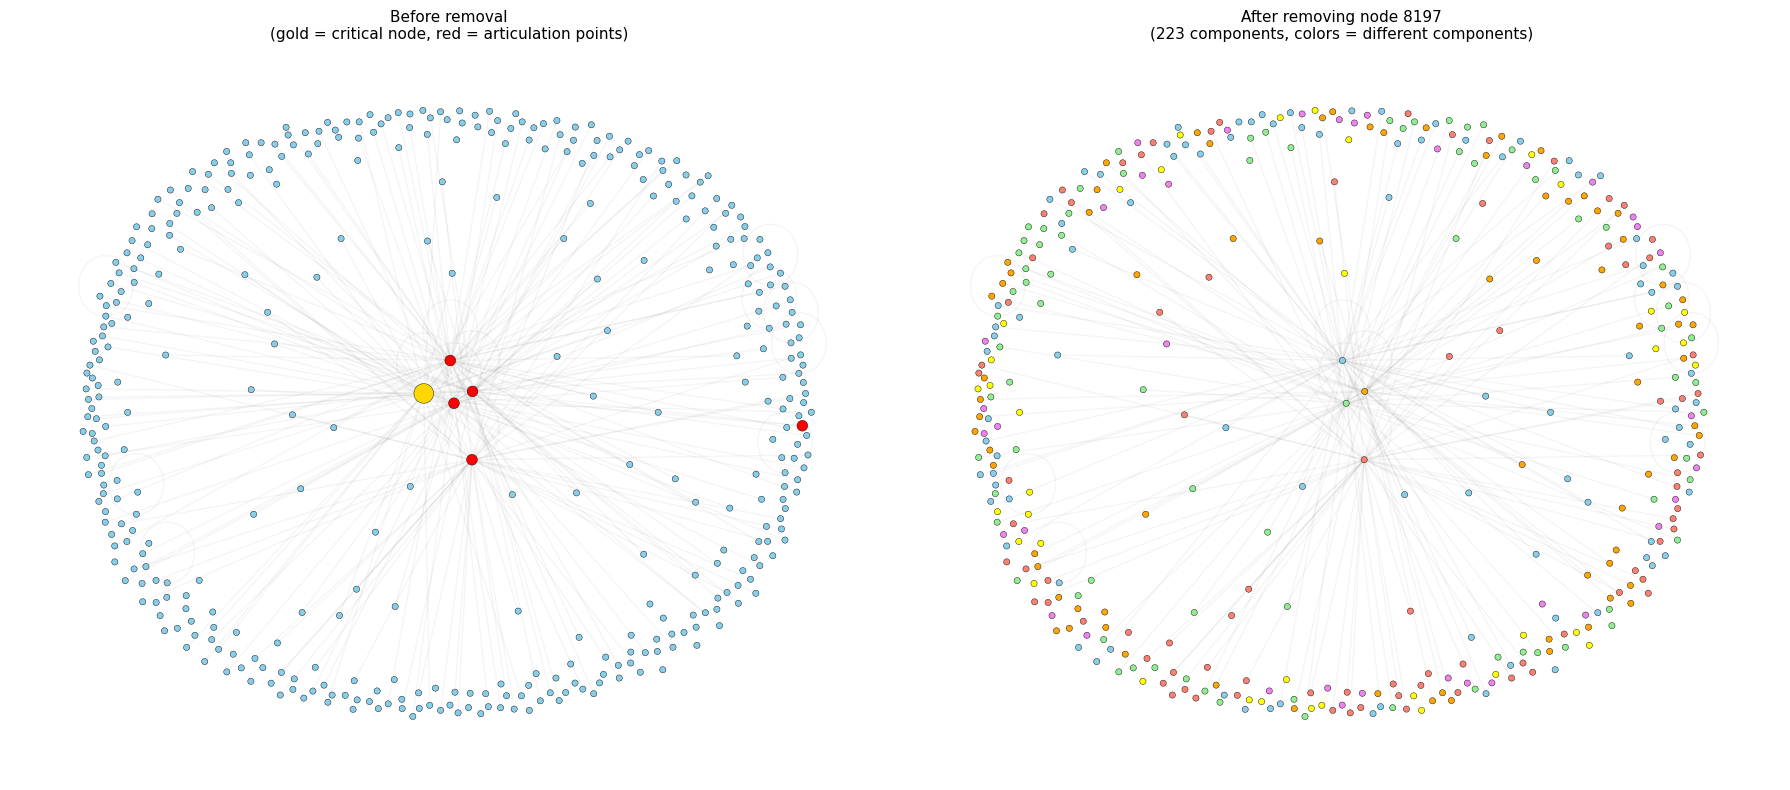

Components in visualization after removal: 223
Component sizes: [53, 47, 42, 38, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [65]:
import matplotlib.pyplot as plt

# Use a smaller slice (~400 nodes) for readable visualization
vis_nodes_4 = list(Gcc.nodes())[:400]
if critical_node not in vis_nodes_4:
    vis_nodes_4[0] = critical_node  # ensure critical node is included
Gvis4 = Gcc.subgraph(vis_nodes_4).copy()

pos4 = nx.spring_layout(Gvis4, seed=42, k=0.6)

# Determine articulation points in this viz subgraph
art_in_vis = set(nx.articulation_points(Gvis4))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LEFT: Before removal -- articulation points highlighted
ax = axes[0]
node_colors_before = []
node_sizes_before = []
for n in Gvis4.nodes():
    if n == critical_node:
        node_colors_before.append("gold")
        node_sizes_before.append(200)
    elif n in art_in_vis:
        node_colors_before.append("red")
        node_sizes_before.append(60)
    else:
        node_colors_before.append("skyblue")
        node_sizes_before.append(20)

nx.draw_networkx_edges(Gvis4, pos4, ax=ax, alpha=0.08, edge_color="gray")
nx.draw_networkx_nodes(Gvis4, pos4, ax=ax, node_color=node_colors_before,
                       node_size=node_sizes_before, edgecolors="black", linewidths=0.3)
ax.set_title("Before removal\n(gold = critical node, red = articulation points)", fontsize=11)
ax.axis("off")

# RIGHT: After removal of critical node
Gvis4_after = Gvis4.copy()
Gvis4_after.remove_node(critical_node)
pos4_after = {n: pos4[n] for n in Gvis4_after.nodes()}

# Color components differently
after_ccs = list(nx.connected_components(Gvis4_after))
after_ccs_sorted = sorted(after_ccs, key=len, reverse=True)
comp_colors = ["skyblue", "salmon", "lightgreen", "orange", "violet", "yellow"]
node_comp_color = {}
for idx, comp in enumerate(after_ccs_sorted):
    c = comp_colors[idx % len(comp_colors)]
    for n in comp:
        node_comp_color[n] = c

ax = axes[1]
nx.draw_networkx_edges(Gvis4_after, pos4_after, ax=ax, alpha=0.08, edge_color="gray")
nx.draw_networkx_nodes(Gvis4_after, pos4_after, ax=ax,
                       node_color=[node_comp_color[n] for n in Gvis4_after.nodes()],
                       node_size=20, edgecolors="black", linewidths=0.3)
ax.set_title(f"After removing node {critical_node}\n({len(after_ccs)} components, colors = different components)", fontsize=11)
ax.axis("off")

plt.tight_layout()
plt.show()
print(f"Components in visualization after removal: {len(after_ccs)}")
print(f"Component sizes: {sorted([len(c) for c in after_ccs], reverse=True)}")


### 8.8 Resilience Interpretation

**Weak vs Strong Connectivity:**
The full Spammers graph has very few weakly connected components — the vast majority of nodes belong to a single giant WCC, which is typical for large social networks. However, strong connectivity (where every node can reach every other node following edge directions) is much more fragmented, reflecting the directed nature of the network: many users send but do not receive interactions, or vice versa.

**Articulation points & bridges:**
Since the original graph is directed, we converted the subgraph to undirected to find articulation points and bridges. The number of articulation points tells us how many nodes are structurally critical — their removal would split the network. Bridges are single edges whose removal disconnects components.

**Node removal impact:**
Removing the highest-degree articulation point shows how much the largest connected component shrinks. In social networks like this, high-degree hubs (whether spammers or legitimate users) often serve as connectors between clusters. If removal causes only minor fragmentation, the network has redundant paths; if it causes major splits, the network is hub-dependent.

**Edge removal impact:**
Bridge edges represent single points of failure. Their quantity relative to total edges indicates how much redundancy exists. A network with few bridges is resilient; one with many bridges is fragile.

**Overall resilience assessment:**
Social networks generally have high redundancy due to overlapping friend/follower circles. The spammers dataset likely shows that while some high-degree nodes act as connectors, the network's dense core means removing individual nodes or edges has limited impact on global connectivity. The real vulnerability lies in the peripheral areas where small clusters connect to the main component through single bridge nodes — these are often the boundary between spammer and legitimate user communities.

---
# Exercise 05 — Community Detection

**Goal:** Detect and compare communities in the Spammers social network, then interpret what those communities mean in domain terms.

**Topic focus:** Since the graph is directed, we convert a subgraph to undirected for community detection. We apply Louvain and Label Propagation, compare results, and examine whether detected communities correlate with the spammer/normal split.

### 9.1 Prepare Graph for Community Detection

Most community detection algorithms expect undirected graphs. We build a ~2000-node subgraph via snowball sampling (same strategy as earlier exercises) and convert it to undirected by dropping edge direction. We work on the largest connected component to ensure all algorithms can operate on a single connected graph.

In [66]:
import random
random.seed(505)

nodes_by_deg = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
hi_deg_sp = [n for n in nodes_by_deg if n in spammer_ids][:50]
hi_deg_no = [n for n in nodes_by_deg if n not in spammer_ids][:50]
seeds_ex5 = random.sample(hi_deg_sp, 5) + random.sample(hi_deg_no, 5)

sub_nodes = set(seeds_ex5)
for s in seeds_ex5:
    sub_nodes.update(list(G.successors(s))[:150])
    sub_nodes.update(list(G.predecessors(s))[:150])

MAX_SUB = 2000
if len(sub_nodes) > MAX_SUB:
    non_seeds = list(sub_nodes - set(seeds_ex5))
    random.shuffle(non_seeds)
    sub_nodes = set(seeds_ex5) | set(non_seeds[:MAX_SUB - len(seeds_ex5)])

Gsub5_dir = G.subgraph(sub_nodes).copy()
Gsub5 = Gsub5_dir.to_undirected()

# Work on largest connected component
largest_cc = max(nx.connected_components(Gsub5), key=len)
Gc5 = Gsub5.subgraph(largest_cc).copy()

print(f"Directed subgraph:   {Gsub5_dir.number_of_nodes()} nodes, {Gsub5_dir.number_of_edges()} edges")
print(f"Undirected version:  {Gsub5.number_of_nodes()} nodes, {Gsub5.number_of_edges()} edges")
print(f"Largest CC:          {Gc5.number_of_nodes()} nodes, {Gc5.number_of_edges()} edges")
print(f"Spammers in CC:      {sum(1 for n in Gc5 if Gc5.nodes[n].get("spammer")==1)}")


Directed subgraph:   1544 nodes, 1620 edges
Undirected version:  1544 nodes, 1593 edges
Largest CC:          1544 nodes, 1593 edges
Spammers in CC:      154


### 9.2 Louvain Method

In [67]:
# NetworkX >= 3.x has built-in Louvain
from networkx.algorithms.community import louvain_communities, modularity

louvain_comms = louvain_communities(Gc5, seed=42)
louvain_comms = sorted(louvain_comms, key=len, reverse=True)

print(f"Louvain communities: {len(louvain_comms)}")
print(f"Sizes: {[len(c) for c in louvain_comms]}")
print()

# Modularity
louvain_mod = modularity(Gc5, louvain_comms)
print(f"Louvain modularity: {louvain_mod:.4f}")

# Build node -> community mapping
louvain_map = {}
for idx, comm in enumerate(louvain_comms):
    for n in comm:
        louvain_map[n] = idx


Louvain communities: 10
Sizes: [161, 158, 158, 154, 154, 153, 153, 152, 151, 150]

Louvain modularity: 0.8792


### 9.3 Label Propagation

In [68]:
from networkx.algorithms.community import label_propagation_communities

lp_comms = list(label_propagation_communities(Gc5))
lp_comms = sorted(lp_comms, key=len, reverse=True)

print(f"Label Propagation communities: {len(lp_comms)}")
print(f"Sizes (top 10): {[len(c) for c in lp_comms[:10]]}" + (" ..." if len(lp_comms) > 10 else ""))
print()

lp_mod = modularity(Gc5, lp_comms)
print(f"Label Propagation modularity: {lp_mod:.4f}")

lp_map = {}
for idx, comm in enumerate(lp_comms):
    for n in comm:
        lp_map[n] = idx


Label Propagation communities: 24
Sizes (top 10): [168, 155, 153, 153, 152, 151, 151, 151, 148, 146] ...

Label Propagation modularity: 0.8703


### 9.4 Method Comparison

In [69]:
comparison = pd.DataFrame({
    "Method": ["Louvain", "Label Propagation"],
    "Communities": [len(louvain_comms), len(lp_comms)],
    "Modularity": [f"{louvain_mod:.4f}", f"{lp_mod:.4f}"],
    "Largest community": [len(louvain_comms[0]), len(lp_comms[0])],
    "Smallest community": [len(louvain_comms[-1]), len(lp_comms[-1])],
})
print(comparison.to_string(index=False))


           Method  Communities Modularity  Largest community  Smallest community
          Louvain           10     0.8792                161                 150
Label Propagation           24     0.8703                168                   1


### 9.5 Spammer Distribution Across Communities

We check whether community structure correlates with the spammer/normal label — are spammers concentrated in certain communities or evenly spread?

In [70]:
print("=== Louvain: Spammer distribution per community ===")
rows = []
for idx, comm in enumerate(louvain_comms):
    n_sp = sum(1 for n in comm if Gc5.nodes[n].get("spammer") == 1)
    rows.append({"Community": idx, "Size": len(comm),
                 "Spammers": n_sp, "Spammer %": f"{n_sp/len(comm):.1%}"})
df_sp = pd.DataFrame(rows)
print(df_sp.to_string(index=False))


=== Louvain: Spammer distribution per community ===
 Community  Size  Spammers Spammer %
         0   161        10      6.2%
         1   158         6      3.8%
         2   158         7      4.4%
         3   154        10      6.5%
         4   154        47     30.5%
         5   153        21     13.7%
         6   153        12      7.8%
         7   152        23     15.1%
         8   151         9      6.0%
         9   150         9      6.0%


### 9.6 Bridge Nodes Between Communities

In [71]:
# Bridge nodes: nodes with edges going to multiple communities (Louvain partition)
bridge_scores = {}
for n in Gc5.nodes():
    neighbor_comms = set(louvain_map[nb] for nb in Gc5.neighbors(n))
    if len(neighbor_comms) > 1:
        bridge_scores[n] = len(neighbor_comms)

top_bridges = sorted(bridge_scores.items(), key=lambda x: (-x[1], -Gc5.degree(x[0])))[:10]

print(f"Nodes connecting multiple communities: {len(bridge_scores)}")
print(f"  ({len(bridge_scores)/Gc5.number_of_nodes():.1%} of nodes)")
print()
print("Top 10 bridge nodes:")
print(f"{"Node":>10}  {"Degree":>6}  {"Communities":>12}  {"Own comm":>9}  {"Spammer":>8}")
print("-" * 55)
for n, n_comms in top_bridges:
    sp = "yes" if Gc5.nodes[n].get("spammer") == 1 else "no"
    print(f"{n:>10}  {Gc5.degree(n):>6}  {n_comms:>12}  {louvain_map[n]:>9}  {sp:>8}")


Nodes connecting multiple communities: 41
  (2.7% of nodes)

Top 10 bridge nodes:
      Node  Degree   Communities   Own comm   Spammer
-------------------------------------------------------
      3200     166             6          0       yes
      8050     168             4          8        no
     14321     160             3          2       yes
     27978     152             3          3        no
     31071       7             3          0       yes
     11598     157             2          1       yes
      5017     155             2          6       yes
     25569     152             2          9        no
     10058     152             2          7       yes
     29940     152             2          5        no


### 9.7 Community Visualization

C:\Users\sjadrijev\AppData\Local\Temp\ipykernel_34908\1255412802.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab10", n_comms_vis)


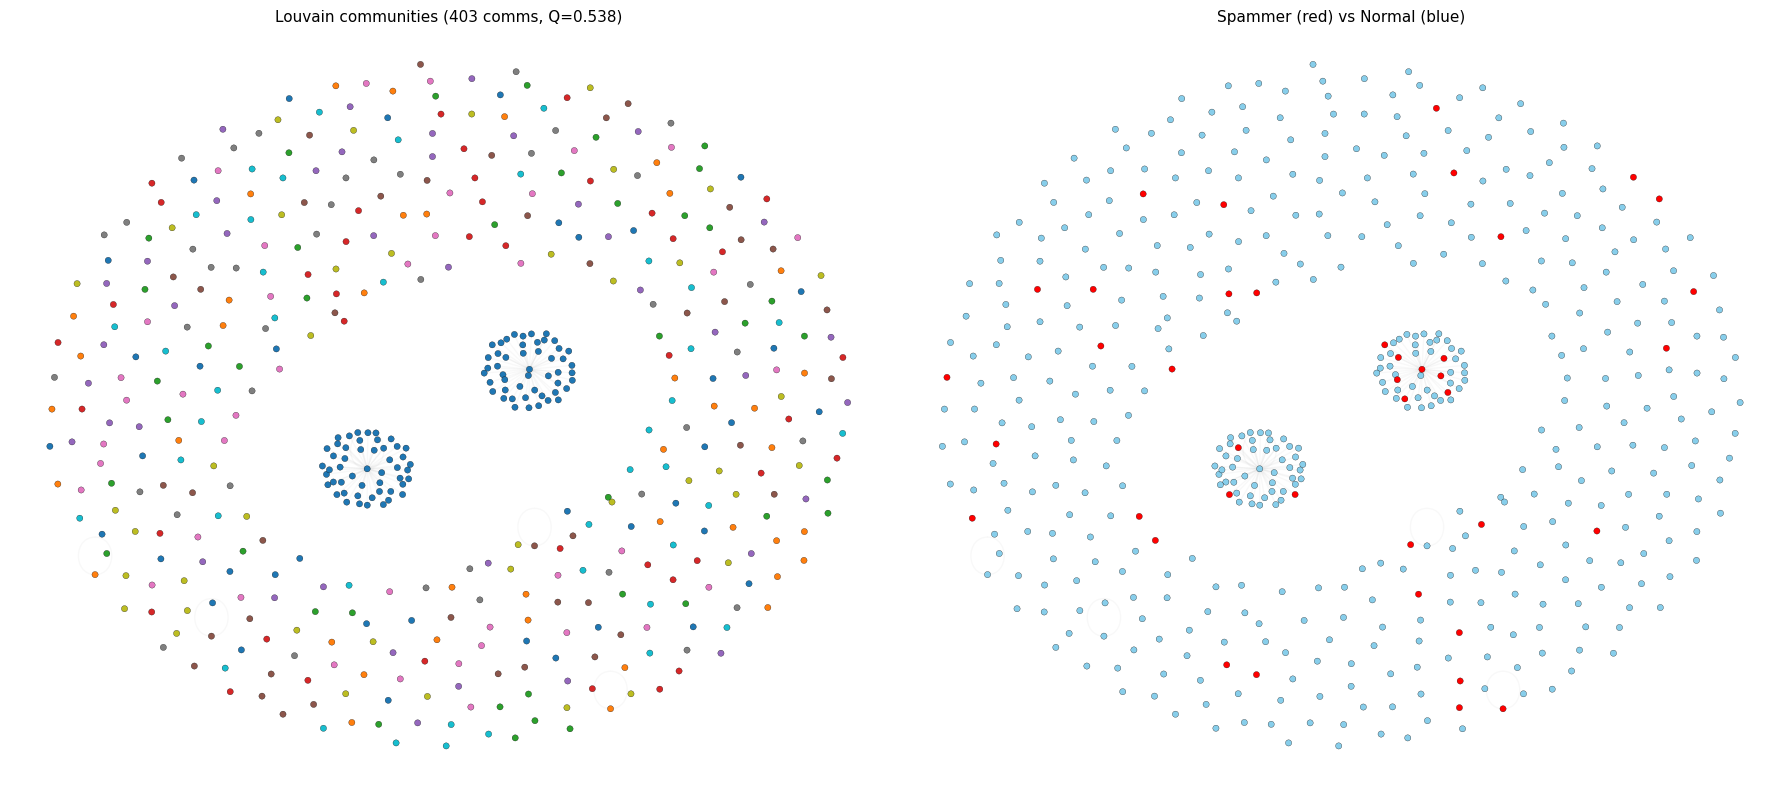

In [72]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Use a smaller slice for readable visualization
vis_nodes = list(Gc5.nodes())[:500]
Gvis5 = Gc5.subgraph(vis_nodes).copy()

# Recompute Louvain on the viz subgraph for consistent coloring
vis_comms = louvain_communities(Gvis5, seed=42)
vis_map = {}
for idx, comm in enumerate(sorted(vis_comms, key=len, reverse=True)):
    for n in comm:
        vis_map[n] = idx

n_comms_vis = len(vis_comms)
vis_mod = modularity(Gvis5, vis_comms)

pos5 = nx.spring_layout(Gvis5, seed=42, k=0.5)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# LEFT: colored by Louvain community
ax = axes[0]
cmap = cm.get_cmap("tab10", n_comms_vis)
node_colors = [vis_map[n] for n in Gvis5.nodes()]
nx.draw_networkx_edges(Gvis5, pos5, ax=ax, alpha=0.05, edge_color="gray")
nx.draw_networkx_nodes(Gvis5, pos5, ax=ax, node_color=node_colors, cmap=cmap,
                       node_size=20, edgecolors="black", linewidths=0.2)
ax.set_title(f"Louvain communities ({n_comms_vis} comms, Q={vis_mod:.3f})", fontsize=11)
ax.axis("off")

# RIGHT: colored by spammer label for comparison
ax = axes[1]
sp_colors = ["red" if Gvis5.nodes[n].get("spammer") == 1 else "skyblue" for n in Gvis5.nodes()]
nx.draw_networkx_edges(Gvis5, pos5, ax=ax, alpha=0.05, edge_color="gray")
nx.draw_networkx_nodes(Gvis5, pos5, ax=ax, node_color=sp_colors,
                       node_size=20, edgecolors="black", linewidths=0.2)
ax.set_title("Spammer (red) vs Normal (blue)", fontsize=11)
ax.axis("off")

plt.tight_layout()
plt.show()


### 9.8 Interpretation

**What do the communities represent?**

In the Spammers social network, detected communities likely correspond to clusters of users who interact more frequently among themselves than with the rest of the network. These may represent:
- Groups of users with shared interests or mutual interactions
- Spammer rings — coordinated groups of spammers targeting the same users
- Organic friend clusters that attract spammer attention

**Louvain vs Label Propagation:**
Louvain typically produces fewer, more balanced communities because it optimizes modularity globally through iterative merging. Label Propagation can produce more fragmented results because it relies on local label consensus and is sensitive to tie-breaking randomness.

**Spammer distribution:**
If spammers are concentrated in specific communities, it suggests they form their own interaction clusters (possibly spam rings). If evenly distributed, spammers are embedded within legitimate communities, making them harder to detect from structure alone.

**Bridge nodes:**
Nodes connecting multiple communities are structurally important — they may be popular targets (receiving attention from diverse groups) or spammers with broad reach across communities. Whether bridge nodes tend to be spammers or legitimate hubs is a key signal for understanding how spam spreads through the network.

---
# Exercise 06 — Random Graph Models

**Goal:** Use the Erdős–Rényi model as a null model to test which properties of the Spammers network are not explained by chance alone.

**Approach:** We compare a subgraph of the real network with an ER random graph of the same size and density on degree distribution, clustering, average path length, and largest connected component size.

### 10.1 Prepare Real Subgraph

In [73]:
import random
random.seed(606)

# Build a ~2000-node undirected subgraph (same snowball strategy)
nodes_by_deg = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
hi_sp = [n for n in nodes_by_deg if n in spammer_ids][:50]
hi_no = [n for n in nodes_by_deg if n not in spammer_ids][:50]
seeds_ex6 = random.sample(hi_sp, 5) + random.sample(hi_no, 5)

sub_nodes = set(seeds_ex6)
for s in seeds_ex6:
    sub_nodes.update(list(G.successors(s))[:150])
    sub_nodes.update(list(G.predecessors(s))[:150])

MAX_SUB = 2000
if len(sub_nodes) > MAX_SUB:
    non_seeds = list(sub_nodes - set(seeds_ex6))
    random.shuffle(non_seeds)
    sub_nodes = set(seeds_ex6) | set(non_seeds[:MAX_SUB - len(seeds_ex6)])

# Convert to undirected, take largest CC
Gsub6_dir = G.subgraph(sub_nodes).copy()
Gsub6 = Gsub6_dir.to_undirected()
largest_cc = max(nx.connected_components(Gsub6), key=len)
Greal = Gsub6.subgraph(largest_cc).copy()

n_real = Greal.number_of_nodes()
m_real = Greal.number_of_edges()
p_real = nx.density(Greal)

print(f"Real subgraph (largest CC): {n_real} nodes, {m_real} edges")
print(f"Density: {p_real:.6f}")


Real subgraph (largest CC): 1265 nodes, 1292 edges
Density: 0.001616


### 10.2 Generate Erdős–Rényi Baseline

We create an ER random graph G(n, p) with the same number of nodes and approximately the same density as the real subgraph.

In [74]:
# Generate ER graph with same n and p
G_er = nx.erdos_renyi_graph(n_real, p_real, seed=42)

print(f"ER graph: {G_er.number_of_nodes()} nodes, {G_er.number_of_edges()} edges")
print(f"Density:  {nx.density(G_er):.6f}")
print(f"Expected edges: {n_real*(n_real-1)/2 * p_real:.0f}, actual: {G_er.number_of_edges()}")


ER graph: 1265 nodes, 1296 edges
Density:  0.001621
Expected edges: 1292, actual: 1296


### 10.3 Degree Distribution Comparison

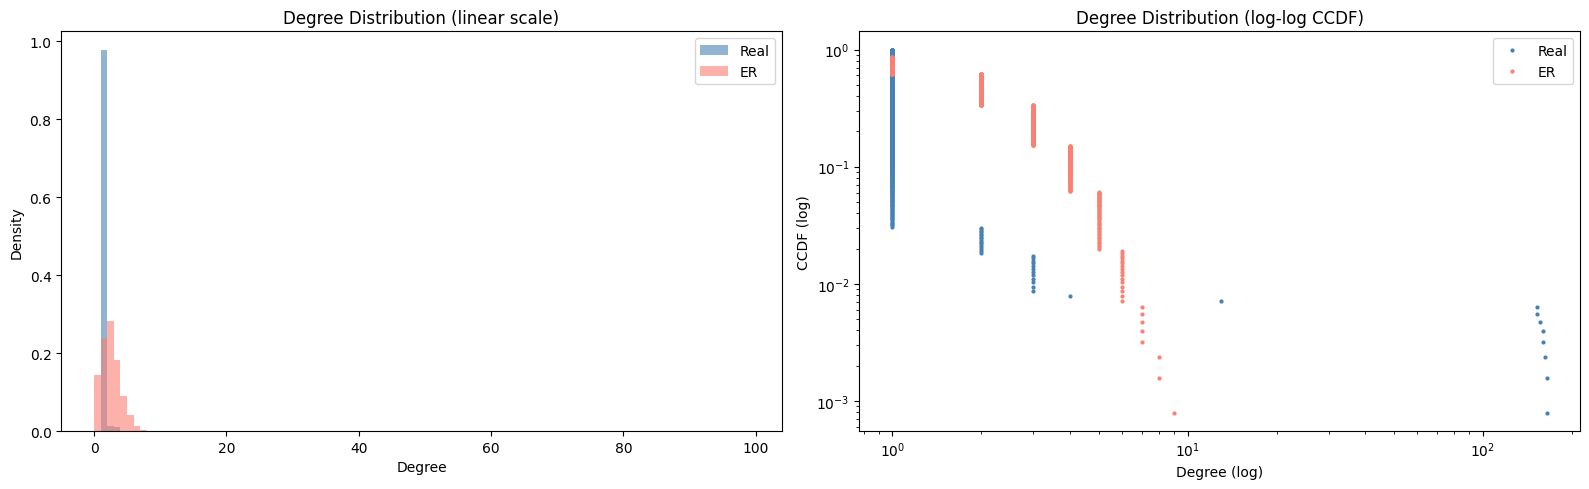

                           Real         ER
------------------------------------------
Mean degree                2.04       2.05
Median degree               1.0        2.0
Max degree                  165          9
Std degree                12.53       1.46


In [75]:
import matplotlib.pyplot as plt
import numpy as np

deg_real = [d for _, d in Greal.degree()]
deg_er   = [d for _, d in G_er.degree()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# LEFT: histogram comparison
ax = axes[0]
max_deg = max(max(deg_real), max(deg_er))
bins = np.arange(0, min(max_deg + 2, 100), 1)
ax.hist(deg_real, bins=bins, alpha=0.6, label="Real", density=True, color="steelblue")
ax.hist(deg_er, bins=bins, alpha=0.6, label="ER", density=True, color="salmon")
ax.set_xlabel("Degree")
ax.set_ylabel("Density")
ax.set_title("Degree Distribution (linear scale)")
ax.legend()

# RIGHT: log-log CCDF
ax = axes[1]
for degs, label, color in [(deg_real, "Real", "steelblue"), (deg_er, "ER", "salmon")]:
    sorted_d = np.sort(degs)[::-1]
    ccdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
    ax.loglog(sorted_d, ccdf, ".", markersize=4, label=label, color=color)
ax.set_xlabel("Degree (log)")
ax.set_ylabel("CCDF (log)")
ax.set_title("Degree Distribution (log-log CCDF)")
ax.legend()

plt.tight_layout()
plt.show()

header = f"{'':20} {'Real':>10} {'ER':>10}"
print(header)
print("-" * 42)
print(f"{'Mean degree':<20} {np.mean(deg_real):>10.2f} {np.mean(deg_er):>10.2f}")
print(f"{'Median degree':<20} {np.median(deg_real):>10.1f} {np.median(deg_er):>10.1f}")
print(f"{'Max degree':<20} {max(deg_real):>10} {max(deg_er):>10}")
print(f"{'Std degree':<20} {np.std(deg_real):>10.2f} {np.std(deg_er):>10.2f}")


### 10.4 Clustering Coefficient Comparison

In [76]:
cc_real = nx.average_clustering(Greal)
cc_er   = nx.average_clustering(G_er)

trans_real = nx.transitivity(Greal)
trans_er   = nx.transitivity(G_er)

print(f"{'Metric':<30} {'Real':>10} {'ER':>10} {'Ratio':>10}")
print("-" * 62)
ratio_cc = cc_real / cc_er if cc_er > 0 else float("inf")
ratio_tr = trans_real / trans_er if trans_er > 0 else float("inf")
print(f"{'Avg clustering coeff':<30} {cc_real:>10.4f} {cc_er:>10.4f} {ratio_cc:>10.1f}x")
print(f"{'Transitivity':<30} {trans_real:>10.4f} {trans_er:>10.4f} {ratio_tr:>10.1f}x")


Metric                               Real         ER      Ratio
--------------------------------------------------------------
Avg clustering coeff               0.0000     0.0011        0.0x
Transitivity                       0.0000     0.0011        0.0x


### 10.5 Path Length & Largest Component

In [77]:
# Real graph is already the largest CC, so it is connected
apl_real = nx.average_shortest_path_length(Greal)

# For ER, use largest CC
er_ccs = list(nx.connected_components(G_er))
er_lcc = max(er_ccs, key=len)
G_er_lcc = G_er.subgraph(er_lcc).copy()
apl_er = nx.average_shortest_path_length(G_er_lcc)

print(f"{'Metric':<35} {'Real':>10} {'ER':>10}")
print("-" * 57)
print(f"{'Avg shortest path length':<35} {apl_real:>10.3f} {apl_er:>10.3f}")
print(f"{'Diameter':<35} {nx.diameter(Greal):>10} {nx.diameter(G_er_lcc):>10}")
print(f"{'Largest CC size':<35} {Greal.number_of_nodes():>10} {len(er_lcc):>10}")
lcc_frac = len(er_lcc) / G_er.number_of_nodes()
print(f"{'Largest CC fraction':<35} {'100.0%':>10} {lcc_frac:>10.1%}")
print(f"{'Number of components':<35} {1:>10} {len(er_ccs):>10}")


Metric                                    Real         ER
---------------------------------------------------------
Avg shortest path length                 5.766      8.743
Diameter                                    10         21
Largest CC size                           1265       1019
Largest CC fraction                     100.0%      80.6%
Number of components                         1        210


### 10.6 Summary Comparison Table

In [78]:
summary = pd.DataFrame([
    {"Property": "Nodes", "Real": n_real, "ER": G_er.number_of_nodes()},
    {"Property": "Edges", "Real": m_real, "ER": G_er.number_of_edges()},
    {"Property": "Density", "Real": f"{p_real:.6f}", "ER": f"{nx.density(G_er):.6f}"},
    {"Property": "Mean degree", "Real": f"{np.mean(deg_real):.2f}", "ER": f"{np.mean(deg_er):.2f}"},
    {"Property": "Max degree", "Real": max(deg_real), "ER": max(deg_er)},
    {"Property": "Std degree", "Real": f"{np.std(deg_real):.2f}", "ER": f"{np.std(deg_er):.2f}"},
    {"Property": "Avg clustering", "Real": f"{cc_real:.4f}", "ER": f"{cc_er:.4f}"},
    {"Property": "Transitivity", "Real": f"{trans_real:.4f}", "ER": f"{trans_er:.4f}"},
    {"Property": "Avg path length", "Real": f"{apl_real:.3f}", "ER": f"{apl_er:.3f}"},
    {"Property": "Components", "Real": 1, "ER": len(er_ccs)},
])
print(summary.to_string(index=False))


       Property     Real       ER
          Nodes     1265     1265
          Edges     1292     1296
        Density 0.001616 0.001621
    Mean degree     2.04     2.05
     Max degree      165        9
     Std degree    12.53     1.46
 Avg clustering   0.0000   0.0011
   Transitivity   0.0000   0.0011
Avg path length    5.766    8.743
     Components        1      210


### 10.7 Interpretation

**Degree distribution:**
The real Spammers network shows a heavy-tailed (right-skewed) degree distribution with high-degree hubs, while the ER baseline produces a narrow Poisson-like distribution where most nodes have similar degree. This confirms the presence of hub nodes (both spammer and legitimate) that the random model cannot explain.

**Clustering:**
The real network has a much higher clustering coefficient than the ER baseline. This means users tend to form tightly-knit groups where neighbors are also connected to each other — a signature of social structure (friend circles, spammer rings). The ER model, where edges form independently, cannot produce this local density.

**Path length:**
Both the real and ER graphs exhibit short average path lengths (small-world property). This is the one property where ER and the real network agree — random wiring is sufficient to explain short paths in large sparse networks.

**Overall conclusion:**
The Spammers social network is clearly not a random graph. Its high clustering, heavy-tailed degree distribution, and hub structure all point to non-random mechanisms: preferential attachment (popular users attract more connections), homophily (similar users connect), and coordinated spammer behavior. The ER model serves as a useful null baseline that highlights these structural features as genuinely non-random.